
# Paper‑Exact Diffusion Watermarking (Algorithm 1, **f₁(t)=0**) — **Box watermark (bottom‑right)**
This notebook follows the paper *"Embedding Watermarks in Diffusion Process for Model Intellectual Property Protection"* (Yang, Peng, Jia, 2024) exactly, using a **bottom‑right box** watermark (single channel). It includes baseline t_A visualization, fine‑tuning with Algorithm 1 (f₁=0), post‑tuning visualization, verification, and sampling.


## Setup

In [1]:
import math, matplotlib.pyplot as plt, cv2, torch, torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
import torchvision
from torchvision import transforms
from torchvision.utils import make_grid
from tqdm import tqdm
from diffusers import DDPMPipeline, DDPMScheduler
import copy
import pandas as pd
import numpy as np
from torchmetrics.image.inception import InceptionScore
from torchmetrics.image.fid import FrechetInceptionDistance, NoTrainInceptionV3

import copy
import numpy as np
import torch
import torch.nn.functional as F
from tqdm import tqdm
import matplotlib.pyplot as plt
import cv2
from torchvision.utils import make_grid

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


c:\Users\mike8\anaconda3\envs\pytorch\Lib\site-packages\torch\onnx\_internal\_beartype.py:36: UserWarning: module 'beartype.roar' has no attribute 'BeartypeDecorHintPep585DeprecationWarning'
  warnings.warn(f"{e}")


Device: cuda


## Config

In [2]:
from dataclasses import dataclass

@dataclass
class Config:
    """
    Central configuration for the paper-exact watermarking demo.
    We keep everything in one place so the training loop, verification,
    and sampling can read consistent values.
    """

    # ----------------------------
    # Dataset & pretrained weights
    # ----------------------------
    dataset: str = "CIFAR10"                 # Which dataset the demo uses. Affects t_A choice and channel count.
    model_id: str = "google/ddpm-cifar10-32" # Hugging Face repo for a *pretrained* DDPM (32x32, CIFAR-10).

    # ----------------------------
    # Image geometry (must match the model)
    # ----------------------------
    image_size: int = 32  # Spatial resolution. Must match the pretrained UNet (here: 32x32).
    channels: int = 3     # 3 for RGB datasets (CIFAR/CelebA), 1 for grayscale (MNIST/FashionMNIST).

    # ----------------------------
    # Data loader / fine-tuning subset
    # ----------------------------
    using_subset: bool = True  # Use a subset of the training data for quick fine-tuning (True) or full set (False).
    subset_size: int = 5000  # How many training images to fine-tune on (paper trains from scratch; we fine-tune briefly).
    batch_size: int = 128    # Larger batches = better signal averaging for the watermark gradient, but use what fits in VRAM.
    num_workers: int = 2     # DataLoader workers; increase if the input pipeline becomes the bottleneck.

    # ----------------------------
    # Optimizer / fine-tuning schedule
    # ----------------------------
    lr: float = 2e-4     # AdamW learning rate for *fine-tuning*. Keep modest to preserve pretrained fidelity.
    max_steps: int = 300 # Number of optimizer steps. 200–500 is a good range; too long can degrade image quality.
    use_ema: bool = True # Use EMA(0.999) for RGB datasets (as in the paper) to stabilize sampling quality.

    # ----------------------------
    # Watermark controls (Algorithm 1, f1(t)=0)
    # ----------------------------
    gamma: float = 0.8   # Paper’s γ. During training, targets are γ·ε' + (1−γ)Kx_A; during sampling we divide outputs by γ.

    # t_A specifies the split between "Embedding" (t ≤ t_A) and "Simulation" (t > t_A).
    # The paper uses: CIFAR/Fashion -> t_A ≈ 3/4·T; MNIST/CelebA -> t_A ≈ 1/2·T.
    tA_frac_cifar: float = 0.75  # fraction of T for CIFAR/Fashion
    tA_frac_other: float = 0.5  # fraction of T for MNIST/CelebA

    # ----------------------------
    # BOX watermark pattern (bottom-right), single channel
    # ----------------------------
    box_size: int = 8           # Side length of the filled square watermark in pixels (on a 32x32 canvas).
    box_margin: int = 2         # Pixels the box sits *inward* from the bottom and right borders.
    which_channel_rgb: int = 1  # Which RGB channel holds the watermark: 0=R, **1=G**, 2=B. We default to green.

    # ----------------------------
    # Sampling (qualitative visualization)
    # ----------------------------
    n_final_samples: int = 36   # Number of images to generate for a grid after fine-tuning.
    sample_steps: int = 1000    # Reverse-diffusion steps. 1000 ≈ training T (paper-like); 250 is faster but lower fidelity.

    # ----------------------------
    # Verification at t_A (statistical reveal of the watermark)
    # ----------------------------
    verify_batches: int = 10     # How many independent averages to compute for stability.
    verify_batch_size: int = 256 # How many trajectories per average at t_A (higher = stronger SNR for the watermark).
    contour_threshold: float = 0.3  # Success threshold for ROI-restricted contour distance (lower is better).
                                   # Tune per dataset/box size; 0.2–0.4 typically works.

    finetune_sweep = [100, 200, 300, 500, 1000]  # Ablate fine-tuning steps for verification (e.g. [100,200,300,400]).

# Materialize the config so downstream code can read `cfg.<field>`.
cfg = Config()
print(cfg)


Config(dataset='CIFAR10', model_id='google/ddpm-cifar10-32', image_size=32, channels=3, using_subset=True, subset_size=5000, batch_size=128, num_workers=2, lr=0.0002, max_steps=300, use_ema=True, gamma=0.8, tA_frac_cifar=0.75, tA_frac_other=0.5, box_size=8, box_margin=2, which_channel_rgb=1, n_final_samples=36, sample_steps=1000, verify_batches=10, verify_batch_size=256, contour_threshold=0.3)


## Why we use **pretrained weights** (instead of training from scratch)

**Goal of our work.** We want a **watermarking algorithm** that can be *plugged into* existing diffusion models with minimal disruption. The focus is on **how to embed/detect the watermark**, not on re-training a backbone from scratch.

**Why pretrained makes sense here**

- **Isolates the variable of interest.** Starting from a strong, known baseline means any changes we observe come from the **watermarking procedure** (choice of $t_A$, $\gamma$, mask shape), not from random variation in training a model from scratch.

- **Saves compute and time.** Training a from scratch takes **orders of magnitude** more compute than a short fine-tune (hundreds of steps). Our method needs to be **practical** on the existing models.

- **Stability & lower uncertainty.** From-scratch training introduces **uncertainty** in generation quality (FID/IS can vary with seeds, schedules, hyperparameters). With a pretrained model, we keep quality stable and can cleanly measure any watermark side-effects.

- **Reproducibility and comparability.** Pretrained checkpoints are widely shared. Results become easier to reproduce and compare across runs and teams.

- **Deployment realism.** In real pipelines, teams rarely re-train large diffusion models. A watermark that works via **light fine-tuning** is more realistic to adopt.

**How we adapt it safely**

- We keep the **original noise schedule** $(\beta_t,\alpha_t,\bar\alpha_t)$ and only apply the watermark **for $t\le t_A$** during fine-tuning.  
- We use **small LR**, **EMA**, and **limited steps** (e.g., 300–1000) to minimize quality drift.  
- We verify quality by sampling before/after, and detect the watermark **statistically near $t_A$** (averaging trajectories).

**What we’d lose by training from scratch**

- Much higher **compute cost** and **iteration time**.  
- Additional **hyperparameter tuning** to recover good baseline quality.  
- Harder to attribute effects to the **watermark** vs. to **training variance**.

**Caveats of the pretrained route (and mitigations)**

- Fine-tuning could slightly shift image style or detail.  
  *Mitigate*: lower LR, shorter runs, use EMA, keep $\gamma$ moderate, and monitor samples.  
- Watermark signal might be weaker than from-scratch training with a bespoke schedule.  
  *Mitigate*: more fine-tune steps, increase averaging at $t_A$, adjust box size or $\gamma$ if needed.

**Bottom line:** Using **pretrained weights** lets us evaluate the **watermarking algorithm itself**—quickly, reproducibly, and with minimal risk to generation quality—while staying aligned with how models are actually used in practice.


## Dataset, selecting the dataset we would like to use, using CIFAR10 here as the pre-trained model we used is

In [3]:
if cfg.dataset.upper() == "CIFAR10":
    transform = transforms.Compose([
        transforms.Resize(cfg.image_size),
        transforms.ToTensor(),
        transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5)),
    ])
    trainset = torchvision.datasets.CIFAR10(root="./data", train=True, download=True, transform=transform)
    cfg.channels = 3
    tA_frac = cfg.tA_frac_cifar
elif cfg.dataset.upper() == "MNIST":
    transform = transforms.Compose([
        transforms.Resize(cfg.image_size),
        transforms.ToTensor(),
        transforms.Normalize((0.5,),(0.5,)),
    ])
    trainset = torchvision.datasets.MNIST(root="./data", train=True, download=True, transform=transform)
    cfg.channels = 1
    tA_frac = cfg.tA_frac_other
else:
    raise ValueError("Unsupported dataset")


idx = np.random.choice(len(trainset), size=min(cfg.subset_size, len(trainset)), replace=False)
subset = Subset(trainset, idx) if cfg.using_subset else trainset
train_loader = DataLoader(subset, batch_size=cfg.batch_size, shuffle=True, num_workers=cfg.num_workers, pin_memory=True)
len(train_loader)


Files already downloaded and verified


40

## [Baseline] DDPM

A denoising diffusion probabilistic model (DDPM) corrupts data in $T$ small Gaussian-noise steps and learns to reverse them.

**Forward (corruption) process**
$$
q(x_t \mid x_{t-1})=\mathcal N\!\big(\sqrt{\alpha_t}\,x_{t-1},\,\beta_t I\big)
\quad\Longleftrightarrow\quad
q(x_t \mid x_0)=\mathcal N\!\big(\sqrt{\bar{\alpha}_t}\,x_0,\,(1-\bar{\alpha}_t)I\big),
$$
with
$$
\alpha_t = 1-\beta_t, \qquad
\bar{\alpha}_t=\prod_{s=1}^t \alpha_s .
$$

**Reverse (generation) step (ε-prediction parameterization)**
$$
p_\theta(x_{t-1}\!\mid x_t)=\mathcal N\!\big(\mu_\theta(x_t,t),\,\tilde{\beta}_t I\big),
$$
$$
\mu_\theta(x_t,t)=\frac{1}{\sqrt{\alpha_t}}\!\left(x_t-\frac{\beta_t}{\sqrt{1-\bar{\alpha}_t}}\,\varepsilon_\theta(x_t,t)\right),
\qquad
\tilde{\beta}_t=\frac{1-\bar{\alpha}_{t-1}}{1-\bar{\alpha}_t}\,\beta_t .
$$

---

### Annotations

- **$x_0$**: a *clean* data sample (e.g., an image from the dataset).  
- **$x_t$**: the same sample after $t$ steps of forward noising ($t=1,\dots,T$).  
  - As $t$ grows, $x_t$ becomes more like pure Gaussian noise; we typically start sampling from $x_T\sim\mathcal N(0,I)$.
- **$\varepsilon$**: standard Gaussian noise $\mathcal N(0,I)$ used to corrupt $x_0$;  
  **$\varepsilon_\theta(x_t,t)$**: the neural network’s prediction of that noise during reverse steps.
- **$\beta_t$**: the **per-step noise variance** added at step $t$ in the forward process.  
  - Chosen by a **noise schedule** (e.g., linear or cosine). Fixed during training and must be the same at sampling time.
- **$\alpha_t$**: the **signal keep-rate** at step $t$, defined by $\alpha_t=1-\beta_t$.  
  - Coefficient in the mean of $q(x_t\mid x_{t-1})$; larger $\alpha_t$ means we keep more of $x_{t-1}$ and add less noise.
- **$\bar{\alpha}_t$**: the **cumulative** keep-rate up to step $t$, $\bar{\alpha}_t=\prod_{s=1}^t \alpha_s$.  
  - Appears in the closed form $q(x_t\mid x_0)$:
    $x_t=\sqrt{\bar{\alpha}_t}\,x_0+\sqrt{1-\bar{\alpha}_t}\,\varepsilon$.
- **$\tilde{\beta}_t$**: the **posterior** variance used in the reverse step; derived from $\beta_t$ and $\bar{\alpha}_t$ (formula above).
- **$t$**: the diffusion **timestep index** (an integer).  
  - $t=0$ corresponds to clean data; $t=T$ is the noisiest state.

**Intuition.** Each forward step keeps a fraction $\sqrt{\alpha_t}$ of the current signal and injects noise with scale $\sqrt{\beta_t}$. Over many steps the signal-to-noise ratio
$$
\mathrm{SNR}_t=\frac{\bar{\alpha}_t}{1-\bar{\alpha}_t}
$$
shrinks smoothly. The model learns to predict the added noise so the reverse Gaussian updates can iteratively recover a clean sample.


# [Watermarked] Embedding Watermarks in Diffusion Process for Model Intellectual Property Protection

**Goal.** Embed a *statistical* watermark into a pretrained DDPM so final images look normal, but the mark is detectable around a chosen midpoint $t_A$ by averaging trajectories.

---

### A. Quick DDPM recap (notation)

We use a noise schedule $\{\beta_t\}_{t=1}^T$, with $\alpha_t=1-\beta_t$ and $\bar{\alpha}_t=\prod_{s=1}^t \alpha_s$.
The forward corruption has the closed form

$$
q(x_t \mid x_0)=\mathcal N\!\big(\sqrt{\bar{\alpha}_t}\,x_0,\ (1-\bar{\alpha}_t)I\big),
$$

so

$$
x_t=\sqrt{\bar{\alpha}_t}\,x_0+\sqrt{1-\bar{\alpha}_t}\,\varepsilon,\qquad \varepsilon\sim\mathcal N(0,I).
$$

---

### B. The watermark pattern and when it acts

* **Pattern** $x_A$: a fixed mask with the same spatial size as the data (here: a filled box in the bottom-right of one channel).
* **Split time** $t_A$: watermark is **embedded only for steps $t\le t_A$**; after that we simulate normally.

---

### C. How the watermark is injected during training (for $t\le t_A$)

We slightly **bias the input** fed to the UNet and **shift the target noise** it should predict.

1. **Biased input** (what the UNet sees)

$$
x'_t
=\underbrace{\sqrt{\bar{\alpha}_t}\,x_0+\gamma\sqrt{1-\bar{\alpha}_t}\,\varepsilon'_t}_{\text{normal forward (scaled by }\gamma)}
+\underbrace{(1-\gamma)\big(b_t-\sqrt{\bar{\alpha}_t}\,b_0\big)}_{\text{watermark bias}}
$$

2. **Shifted target** (what the UNet is trained to predict)

$$
\varepsilon''_t=\gamma\,\varepsilon'_t+(1-\gamma)\,K\,x_A
$$

Here:

* $\gamma\in(0,1]$ controls watermark strength (smaller $\gamma\Rightarrow$ stronger watermark).
* $b_t$ is a time-ramped watermark that matches each step’s noise scale:

  $$
  b_t=f_2(t)\,\sqrt{1-\bar{\alpha}_t}\,x_A,\qquad b_0=f_2(0)\,x_A.
  $$
* The ramp $f_2(t)$ grows toward $t_A$ and is normalized to reach $\approx 1$ at $t_A$:

  $$
  h_t=\frac{1-\alpha_t}{\sqrt{1-\bar{\alpha}_t}},\quad
  f_2(t)=K\sum_{s=1}^{t} h_s,\quad
  K=\Big(\sum_{s=1}^{t_A} h_s\Big)^{-1}.
  $$

**Intuition.** The input gets a small, schedule-matched push toward the spatial pattern $x_A$, and the target noise includes a tiny constant component in the same direction. Over many steps up to $t_A$, this bias accumulates.

---

### D. After $t_A$ and at sampling time

* **For $t>t_A$** (during training): no more injection; we simulate the usual forward from the already-watermarked $x'_{t_A}$:

  $$
  x'_t=\sqrt{\frac{\bar{\alpha}_t}{\bar{\alpha}_{t_A}}}\,x'_{t_A}
      +\sqrt{1-\frac{\bar{\alpha}_t}{\bar{\alpha}_{t_A}}}\,\varepsilon'_t,\qquad
  \varepsilon''_t=\varepsilon'_t.
  $$
* **Sampling (generation):** no injection at all. With the $f_1(t)=0$ setup used here, we divide the final sample by $\gamma$ once at the end.
  The watermark is **not visible** in final images; it becomes **statistically visible near $t_A$** by averaging many trajectories.




In [4]:
# Load a pretrained DDPM from Hugging Face. The pipeline bundles:
#   - unet: the ε-predictor (noise prediction network)
#   - scheduler: the diffusion schedule (betas/alphas and reverse-step logic)
# Moving it to `device` avoids host↔device copies on every call.
pipe = DDPMPipeline.from_pretrained(cfg.model_id).to(device)

# Configure tqdm inside diffusers' sampling loops. `disable=False` means
# progress bars are SHOWN (set True to silence them).
pipe.set_progress_bar_config(disable=False)

# Pull out the components we’ll use directly.
unet = pipe.unet                                 # εθ(x_t, t): predicts noise given (x_t, t)
scheduler: DDPMScheduler = pipe.scheduler        # holds α_t / β_t schedules and reverse-step formulas

# Number of *training* diffusion steps (typically 1000). This is the length of the
# native schedule used to create x_t during training: t ∈ {0, …, T-1}.
T = scheduler.config.num_train_timesteps

# ᾱ_t (alphas_cumprod): cumulative product of per-step α_t up to t.
# It appears in the forward noising rule:
#   x_t = √ᾱ_t · x_0 + √(1 - ᾱ_t) · ε,  with ε ~ N(0, I).
# We keep these tensors on the same device as the model.
a_bar = scheduler.alphas_cumprod.to(device)      # shape: [T]

# Recover the per-step α_t from ᾱ_t:
# For t = 0:           α_0 = ᾱ_0
# For t ≥ 1:           α_t = ᾱ_t / ᾱ_{t-1}
alpha = torch.empty_like(a_bar)                  # shape: [T]
alpha[0]  = a_bar[0]
alpha[1:] = a_bar[1:] / a_bar[:-1]

# Convenience tensors used all over:
#   √ᾱ_t and √(1-ᾱ_t) are exactly the coefficients in q(x_t | x_0).
sqrt_a_bar     = a_bar.sqrt()                    # √ᾱ_t
sqrt_1m_a_bar  = (1 - a_bar).sqrt()              # √(1 - ᾱ_t)

# Choose the watermark split point t_A as a fraction of the training horizon.
# Paper default: t_A = 3/4 · T for CIFAR/Fashion, 1/2 · T for MNIST/CelebA.
# We cast to int to get a valid discrete index.
tA = int(tA_frac * T)

print("T:", T, "tA:", tA)

Loading pipeline components...:   0%|          | 0/2 [00:00<?, ?it/s]

An error occurred while trying to fetch C:\Users\mike8\.cache\huggingface\hub\models--google--ddpm-cifar10-32\snapshots\267b167dc01f0e4e61923ea244e8b988f84deb80: Error no file named diffusion_pytorch_model.safetensors found in directory C:\Users\mike8\.cache\huggingface\hub\models--google--ddpm-cifar10-32\snapshots\267b167dc01f0e4e61923ea244e8b988f84deb80.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.


T: 1000 tA: 750


## Tons of Helpers here

In [5]:
def show_grid_tensor(imgs, title=""):
    """Display a grid of images given as a single 4D tensor (B,C,H,W) in [-1,1]."""
    grid = make_grid(imgs, nrow=int(math.sqrt(len(imgs))), padding=2)
    npimg = (grid.detach().cpu().permute(1,2,0).numpy() * 255).astype(np.uint8)
    plt.figure(figsize=(6,6)); plt.imshow(npimg); plt.axis("off"); plt.title(title); plt.show()


# -----------------------------------------------------------------------------
# Selectively unfreeze a subset of the UNet for faster/safer fine-tuning
# -----------------------------------------------------------------------------

def to_u8(x):
    """
    Convert a float tensor in [0,1] to uint8 [0,255] on CPU.
    Accepts [...,C,H,W] or [C,H,W]; returns same shape on CPU with dtype=uint8.
    """
    return (x.clamp(0, 1) * 255).to(torch.uint8).cpu()

def _to_u8_0_255(x_f01: torch.Tensor) -> torch.Tensor:
    """[B,C,H,W] float in [0,1] -> uint8 [0,255] on CPU."""
    return (x_f01.clamp(0,1) * 255).to(torch.uint8).cpu()

def _collect_real_u8(train_loader, n: int) -> torch.Tensor:
    """
    Pull ~n real images from the dataloader, map from model space [-1,1] to [0,1],
    and return uint8 [0,255]. Stops early if loader exhausts.
    """
    buf = []
    tot = 0
    it = iter(train_loader)
    while tot < n:
        try:
            x, _ = next(it)
        except StopIteration:
            break
        # assume x in [-1,1]; map to [0,1]
        x01 = ((x.to(torch.float32) + 1) * 0.5).clamp(0,1)
        buf.append(_to_u8_0_255(x01))
        tot += x.size(0)
    if not buf:
        raise RuntimeError("No real images collected; check your train_loader.")
    real_u8 = torch.cat(buf, dim=0)[:n]  # [N,C,H,W] uint8 (CPU)
    return real_u8


@torch.no_grad()
def _inception_feats_u8(u8_imgs: torch.Tensor, device: torch.device, batch: int = 128) -> torch.Tensor:
    """
    Extract 2048-d Inception (pool3) features for uint8 images using the
    same backbone that FrechetInceptionDistance uses internally.
    Works across torchmetrics versions.

    Args:
        u8_imgs: [N,C,H,W] uint8 in [0,255] on CPU
        device:  torch.device("cuda" or "cpu")
        batch:   mini-batch size for feature extraction

    Returns:
        feats: [N,2048] float32 on CPU
    """
    from torchmetrics.image.fid import FrechetInceptionDistance

    # Build a dummy FID metric solely to access its 'inception' module
    fid_helper = FrechetInceptionDistance(feature=2048, normalize=False).to(device)
    inc = fid_helper.inception.eval()

    feats = []
    for i in range(0, u8_imgs.shape[0], batch):
        x = u8_imgs[i:i+batch].to(device)            # uint8 on device
        f = inc(x)                                   # usually returns [B,2048]
        if isinstance(f, (tuple, list)):             # safety for older variants
            f = f[0]
        feats.append(f.detach().float().cpu())
    del fid_helper
    return torch.cat(feats, dim=0)

@torch.no_grad()
def _precision_recall_knn(feats_real: torch.Tensor, feats_fake: torch.Tensor, k: int = 3, chunk: int = 1024, device: torch.device = None):
    """
    Precision/Recall (Kynkäänniemi et al., 2019) on Inception features.
    - Precision: frac of fake samples that fall within the k-NN radius of *some* real sample.
    - Recall:    frac of real samples that fall within the k-NN radius of *some* fake sample.
    Inputs: feats_* on CPU [N,2048]; we chunk & push to device for cdist.
    Returns: precision (float), recall (float)
    """
    if device is None:
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    X = feats_real.to(device)  # [Nr, D]
    Y = feats_fake.to(device)  # [Nf, D]

    # kNN radii in *their own* sets (exclude self with +inf on diag)
    def knn_radii(A: torch.Tensor, k: int) -> torch.Tensor:
        n = A.size(0)
        rads = torch.empty(n, device=device)
        for i in range(0, n, chunk):
            j = min(i+chunk, n)
            block = A[i:j]                          # [B,D]
            dist = torch.cdist(block, A, p=2)       # [B,n]
            idx = torch.arange(i, j, device=device)
            dist[torch.arange(j-i, device=device), idx] = float('inf')  # drop self
            # kth nearest neighbor distance
            kth, _ = torch.topk(dist, k, dim=1, largest=False)
            rads[i:j] = kth[:, -1]
        return rads  # [n]

    r_X = knn_radii(X, k=k)  # [Nr]
    r_Y = knn_radii(Y, k=k)  # [Nf]

    # Precision: ∀ y∈Y, ∃ x∈X s.t. ||y-x|| <= r_X[x]
    prec_hits = torch.zeros(Y.size(0), dtype=torch.bool, device=device)
    for i in range(0, X.size(0), chunk):
        j = min(i+chunk, X.size(0))
        d = torch.cdist(Y, X[i:j], p=2)                   # [Nf, j-i]
        thr = r_X[i:j].unsqueeze(0).expand_as(d)          # [Nf, j-i]
        prec_hits |= (d <= thr).any(dim=1)
    precision = float(prec_hits.float().mean().item())

    # Recall: ∀ x∈X, ∃ y∈Y s.t. ||x-y|| <= r_Y[y]
    rec_hits = torch.zeros(X.size(0), dtype=torch.bool, device=device)
    for i in range(0, Y.size(0), chunk):
        j = min(i+chunk, Y.size(0))
        d = torch.cdist(X, Y[i:j], p=2)                   # [Nr, j-i]
        thr = r_Y[i:j].unsqueeze(0).expand_as(d)          # [Nr, j-i]
        rec_hits |= (d <= thr).any(dim=1)
    recall = float(rec_hits.float().mean().item())

    # move back to CPU
    torch.cuda.empty_cache() if device.type == 'cuda' else None
    return precision, recall

def set_trainable(unet, mode: str = "last_block"):
    """
    mode ∈ {"all", "last_conv", "last_block", "last_two_blocks"}.
      - "last_conv": only the final conv_norm_out + conv_out heads
      - "last_block": last up block + conv heads     (recommended)
      - "last_two_blocks": last two up blocks + conv heads
      - "all": train everything (heavier; more drift risk)

    Freezes everything by default, then re-enables the chosen modules.
    Prints how many parameters are trainable to keep you honest about scope.
    """
    # Freeze all params
    for p in unet.parameters():
        p.requires_grad = False

    # Decide which submodules to unfreeze
    modules = []
    if mode == "all":
        modules = [unet]
    elif mode == "last_conv":
        modules = [unet.conv_norm_out, unet.conv_out]
    elif mode == "last_block":
        modules = [unet.up_blocks[-1], unet.conv_norm_out, unet.conv_out]
    elif mode == "last_two_blocks":
        modules = [unet.up_blocks[-2], unet.up_blocks[-1], unet.conv_norm_out, unet.conv_out]
    else:
        raise ValueError(f"Unknown mode: {mode}")

    for m in modules:
        for p in m.parameters():
            p.requires_grad = True

    # Report scope
    tot = sum(p.numel() for p in unet.parameters())
    trn = sum(p.numel() for p in unet.parameters() if p.requires_grad)
    print(f"Trainable params: {trn/1e6:.2f}M / {tot/1e6:.2f}M  ({100*trn/tot:.1f}%), mode='{mode}'")




# Part 1 — Baseline (pretrained) samples

  0%|          | 0/250 [00:00<?, ?it/s]

c:\Users\mike8\anaconda3\envs\pytorch\Lib\site-packages\diffusers\models\attention_processor.py:2383: UserWarning: 1Torch was not compiled with flash attention. (Triggered internally at C:\cb\pytorch_1000000000000\work\aten\src\ATen\native\transformers\cuda\sdp_utils.cpp:555.)
  hidden_states = F.scaled_dot_product_attention(


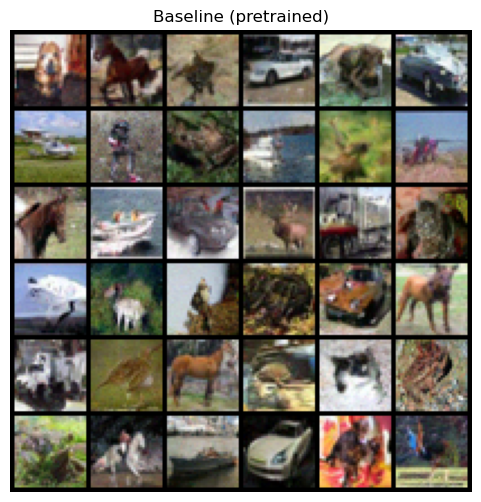

In [6]:
@torch.no_grad()
def sample_pretrained(pipe, num=36, steps=250):
    """Sample from the pretrained model for qualitative visualization."""
    out = pipe(batch_size=num, num_inference_steps=steps)
    arr = []
    for im in out.images:
        arr.append(torch.from_numpy(np.array(im).astype("float32")/255.0).permute(2,0,1))
    return torch.stack(arr, dim=0)

baseline_imgs = sample_pretrained(pipe, num=cfg.n_final_samples, steps=250)
show_grid_tensor(baseline_imgs, "Baseline (pretrained)")


## Paper watermark x_A: bottom‑right **box** (single channel)

## How the watermark is defined in this step

This cell **defines the watermark pattern** and **where it lives**; it does **not** inject it yet.

### 1) Spatial pattern (the mask)
- We build a **binary mask** $x_A \in \mathbb{R}^{C\times H\times W}$:
  - Inside the **bottom-right box** (size `cfg.box_size`, inset by `cfg.box_margin`), the mask value is **1**.
  - Everywhere else it is **0**.
- The mask is placed in **one channel only** (index `WTMK_CH`):
  - Grayscale: `WTMK_CH = 0`.
  - RGB: `WTMK_CH = cfg.which_channel_rgb` (0=R, 1=G, 2=B). We default to **green (1)**.
- This gives the watermark its **shape** (a box) and **location** (bottom-right, selected channel).

### 2) Watermark “value” (how strong it becomes later)
- In this step the mask values are just **0/1**. The **actual strength** is applied **later** during training and depends on:
  - The global knob $\gamma \in (0,1]$ (smaller $\gamma$ ⇒ stronger watermark),
  - A **time ramp** $f_2(t)$ that grows toward the split step $t_A$,
  - The schedule scale $\sqrt{1-\bar{\alpha}_t}$ (matches the noise level),
  - A normalizer $K$ so that the ramp satisfies $f_2(t_A)\approx 1$.
- The time-shaped watermark used during embedding is
  $$
  b_t \;=\; f_2(t)\,\sqrt{1-\bar{\alpha}_t}\;x_A,
  $$
  and the additive input bias (only for $t\le t_A$) is
  $$
  (1-\gamma)\,\bigl(b_t - \sqrt{\bar{\alpha}_t}\,b_0\bigr), \qquad b_0 \;=\; f_2(0)\,x_A.
  $$
  The target noise is shifted by a tiny constant term
  $$
  \varepsilon''_t \;=\; \gamma\,\varepsilon'_t \;+\; (1-\gamma)\,K\,x_A.
  $$

### 3) Takeaway
- **Mask ($x_A$)** decides the **where** and **shape** (box, channel).
- **Hyperparameters** $(\gamma, f_2(t), \sqrt{1-\bar{\alpha}_t}, K)$ decide the **how strong** over time.
- This cell prepares $x_A$ and verifies it visually; actual injection happens later during the fine-tuning loop.


xA channel: 1 nonzero: 64


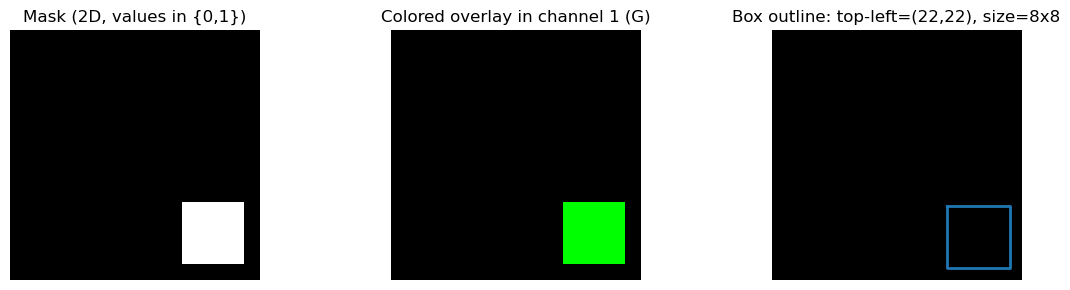

Mask sum (pixels set to 1): 64  |  Expected ~ 64
Channel carrying the mask: WTMK_CH=1  (0=R/gray, 1=G, 2=B for RGB)


In [7]:
# ---------- Visualize the watermark mask ----------

def make_box_mask(H, W, size=8, margin=2):
    """
    Create a binary (0/1) 2D mask with a **filled square box** placed at the
    bottom-right corner of an HxW image.

    Args:
        H (int): Image height in pixels (number of rows, y-axis).
        W (int): Image width in pixels  (number of columns, x-axis).
        size (int): Side length (in pixels) of the square watermark box.
        margin (int): How far the box is inset from the bottom and right edges.

    Returns:
        np.ndarray of shape (H, W), dtype float32:
            Values are 1.0 inside the box and 0.0 elsewhere.

    Notes:
        - Indexing uses NumPy's row-major convention: mask[row, col] = mask[y, x].
        - Slices are **half-open**: [start : end) includes start, excludes end.
        - We clamp the box coordinates to image bounds to avoid index errors
          if `size` or `margin` are configured too large.
    """
    import numpy as np

    # Start with an all-zeros mask (no watermark anywhere).
    mask = np.zeros((H, W), dtype=np.float32)

    # Compute the intended box corners BEFORE clamping:
    #   rows:  r1 .. r2-1   (vertical / y indices)
    #   cols:  c1 .. c2-1   (horizontal / x indices)
    #
    # Place the box 'size' pixels tall/wide, inset by 'margin' from
    # the bottom and right edges.
    r1 = H - margin - size      # top row index of the box
    r2 = H - margin             # one past the bottom row index
    c1 = W - margin - size      # left col index of the box
    c2 = W - margin             # one past the right col index

    # Clamp coordinates to valid image bounds to be safe. This ensures
    # r1<=r2 and c1<=c2 even if the user picks extreme size/margin values.
    r1, c1 = max(0, r1), max(0, c1)
    r2, c2 = min(H, r2), min(W, c2)

    # Fill the region with ones. Because slices are half-open, this writes
    # exactly 'size' pixels in each dimension when not clamped by the border.
    mask[r1:r2, c1:c2] = 1.0

    return mask

# Image geometry taken from the config; must match the pretrained model.
H = W = cfg.image_size
channels = cfg.channels

# Choose WHICH channel carries the watermark:
#   - Grayscale datasets (C=1): channel 0 is the only channel.
#   - RGB datasets (C=3): use cfg.which_channel_rgb (0=R, 1=G, 2=B). We default to green (1),
#     which is common in literature because it balances visibility and perceptual impact.
WTMK_CH = 0 if channels == 1 else int(cfg.which_channel_rgb)

# Build the 2D box mask (NumPy, on CPU). This is the spatial pattern x_A for a single channel.
box = make_box_mask(H, W, size=cfg.box_size, margin=cfg.box_margin)

# Allocate the full watermark tensor xA with shape [C, H, W] on the target device.
# Initialize to zeros so all channels are empty by default.
xA = torch.zeros(channels, H, W, dtype=torch.float32, device=device)

# Insert the box into the selected channel ONLY.
# torch.from_numpy shares memory on CPU; the subsequent .to(device) copies it to the model's device.
# Values are 0.0 outside the box and 1.0 inside; later code scales this dynamically across timesteps,
# so we keep the mask in simple [0,1] form here.
xA[WTMK_CH] = torch.from_numpy(box).to(device)

# Quick sanity print:
#  - "xA channel" confirms which channel we wrote to.
#  - "nonzero" counts how many pixels are set to 1 across all channels (should be ~= size*size unless clamped).
print("xA channel:", WTMK_CH, "nonzero:", int(xA.sum().item()))


# Sanity: the 2D NumPy mask used to build xA
assert isinstance(box, np.ndarray) and box.shape == (H, W), "box should be a 2D NumPy array (H,W)"
# Sanity: xA contains the mask in exactly one channel
assert xA.shape == (channels, H, W), "xA should be (C,H,W)"
assert torch.allclose(xA[WTMK_CH].detach().cpu(), torch.from_numpy(box), atol=1e-6), "xA channel != box mask!"

# 1) Raw 2D mask (white = 1 inside the box, black = 0 elsewhere)
plt.figure(figsize=(12, 3))
plt.subplot(1, 3, 1)
plt.imshow(box, cmap="gray", vmin=0.0, vmax=1.0)
plt.title("Mask (2D, values in {0,1})")
plt.axis("off")

# 2) Colored overlay showing WHICH channel carries the mask
#    - For RGB: put the mask into the selected channel only (0=R, 1=G, 2=B)
#    - For grayscale: just show the mask as gray
plt.subplot(1, 3, 2)
if channels == 3:
    rgb = np.zeros((H, W, 3), dtype=np.float32)
    rgb[..., WTMK_CH] = box  # inject mask into chosen channel
    ch_name = {0: "R", 1: "G", 2: "B"}[WTMK_CH]
    plt.imshow(rgb)  # Matplotlib interprets last dim as RGB
    plt.title(f"Colored overlay in channel {WTMK_CH} ({ch_name})")
else:
    plt.imshow(box, cmap="gray", vmin=0.0, vmax=1.0)
    plt.title("Overlay (grayscale)")
plt.axis("off")

# 3) Box outline (for exact position/size check)
plt.subplot(1, 3, 3)
# Find bounding box from the mask itself (robust if size/margin change)
ys, xs = np.where(box > 0.5)
if xs.size > 0 and ys.size > 0:
    r1, r2 = ys.min(), ys.max() + 1  # +1 because slices are half-open
    c1, c2 = xs.min(), xs.max() + 1
else:
    # Fallback (empty mask) to avoid errors
    r1 = r2 = c1 = c2 = 0

# Draw the rectangle on a blank canvas
plt.imshow(np.zeros((H, W), dtype=np.float32), cmap="gray", vmin=0.0, vmax=1.0)
plt.plot([c1, c2, c2, c1, c1], [r1, r1, r2, r2, r1], linewidth=2)
plt.title(f"Box outline: top-left=({r1},{c1}), size={(r2-r1)}x{(c2-c1)}")
plt.axis("off")
plt.tight_layout()
plt.show()

# Quick numeric summary
print(f"Mask sum (pixels set to 1): {box.sum():.0f}  |  Expected ~ {cfg.box_size*cfg.box_size}")
print(f"Channel carrying the mask: WTMK_CH={WTMK_CH}  (0=R/gray, 1=G, 2=B for RGB)")


## Building the time-dependent watermark weights

In here, we construct the **time ramp** and **scales** that decide *how strongly* the watermark contributes at each diffusion step. It does **not** inject the watermark yet.

### 1) Schedule-aware weight per step
We define
$$
h_t \;=\; \frac{1-\alpha_t}{\sqrt{\,1-\bar{\alpha}_t\,}},
$$
where $\alpha_t=1-\beta_t$ and $\bar{\alpha}_t=\prod_{s=1}^{t}\alpha_s$.  
Intuition: $1-\alpha_t$ is the variance newly added at step $t$; dividing by $\sqrt{1-\bar{\alpha}_t}$ normalizes by the current noise scale so the weight is comparable across timesteps.

### 2) A monotone ramp that peaks at $t_A$
We accumulate and normalize:
$$
\text{cumsum}_h(t)=\sum_{s=0}^{t} h_s, \qquad
K \;=\; \Big(\sum_{s=0}^{t_A} h_s\Big)^{-1}, \qquad
f_2(t) \;=\; K \cdot \text{cumsum}_h(t).
$$
By construction, $f_2(t_A)\approx 1$. This makes $f_2(t)$ a smooth, increasing ramp from near 0 to 1 as $t$ approaches $t_A$.

### 3) Match the watermark to the noise level
We also use
$$
\text{dyn\_scale}(t) \;=\; \sqrt{\,1-\bar{\alpha}_t\,},
$$
so the watermark magnitude tracks the step’s noise scale. The **time-shaped watermark** used later is
$$
b_t \;=\; f_2(t)\,\text{dyn\_scale}(t)\,x_A.
$$

### 4) Centering term and broadcasting helper
We keep
$$
b_0 \;=\; f_2(0)\,x_A,
$$
which appears in the centered bias $(b_t - \sqrt{\bar{\alpha}_t}\,b_0)$ used during embedding; this prevents a drifting offset across $t$. The small `gather` helper simply picks values like $f_2(t)$ or $\text{dyn\_scale}(t)$ for each sample’s timestep and reshapes them to broadcast over a batch of images.

**Takeaway.**  
- $x_A$ (the mask) decides the **where/shape**.  
- $f_2(t)$, $\text{dyn\_scale}(t)$, and $K$ decide the **time profile** so the watermark ramps up and is strongest near $t_A$.  
- $b_0$ ensures the injected bias is properly centered at each step.


In [8]:
# Build the time-dependent weights used to shape the watermark signal.

# h_t = (1 - α_t) / sqrt(1 - ᾱ_t)
# - α_t = 1 - β_t          (per-step "keep-rate")
# - ᾱ_t = ∏_{s=1}^t α_s    (cumulative keep-rate)
# Intuition: h_t grows when the step adds more noise (1-α_t is larger) but is
# tempered by the current noise scale sqrt(1-ᾱ_t). This produces a schedule-
# aware ramp that is stable across timesteps.
h = (1 - alpha) / torch.clamp((1 - a_bar), min=1e-12).sqrt()   # shape: [T]

# Cumulative sum:  cumsum_h[t] = ∑_{s=0}^t h_s
# We'll normalize this so it reaches ~1 exactly at t_A.
cumsum_h = torch.cumsum(h, dim=0)                               # shape: [T]

# Normalizer K so that f2(t_A) ≈ 1.
# K = 1 / ∑_{s=0}^{t_A} h_s
K = 1.0 / float(cumsum_h[tA].item())                            # scalar float

# f2(t) = K * ∑_{s=0}^{t} h_s
# This is a monotone ramp in [0, ~1], with f2(t_A) ≈ 1 by construction.
f2 = K * cumsum_h                                               # shape: [T]

# dyn_scale(t) = sqrt(1 - ᾱ_t)
# This matches the watermark magnitude to the noise scale at time t.
# (You’ll later form b_t = f2(t) * dyn_scale(t) * x_A.)
dyn_scale = sqrt_1m_a_bar                                       # shape: [T]

# Helper to pick per-sample timestep coefficients and expand for broadcasting.
# arr: [T] (e.g., f2, dyn_scale, a_bar, …)
# t:   [B] integer timesteps
# -> returns [B,1,1,1] ready to multiply a [B,C,H,W] tensor
def gather(arr, t): 
    return arr.index_select(0, t).view(-1, 1, 1, 1)

# b0 = f2(0) * x_A
# A small, time-0 watermark term used in the centering expression:
# (b_t - sqrt(ᾱ_t) * b0). Keeping b0 explicit makes the algebra clean and
# prevents a drifting offset when accumulating the bias across timesteps.
b0 = f2[0] * xA                                                 # shape: [C,H,W]

# Sanity check: f2[tA] should be ~1.0 after normalization.
print("K:", float(K), "f2[tA]~", float(f2[tA]))


K: 0.14201386664557492 f2[tA]~ 1.0


## Mid-chain watermark check at $t_A$ — baseline vs. injected (diagnostic)

**Purpose.** This cell compares two ways of looking for the watermark **at the diffusion midpoint $t_A$**:

1. **Baseline (no injection):** sample many clean trajectories from the pretrained model, stop at $t_A$, **average** them to suppress noise, and visualize/measure any residual box signal.  
2. **Injected (diagnostic):** run the same sampler but **actively add** the watermark bias during steps $t \le t_A$ (for inspection only), then stop at $t_A$ and average. This helps you see what a “strong” watermark would look like at the right time.

---

### What gets captured and why we average
- We capture $x_{t_A}$ from **many** independent runs and compute the average $\bar{x}_{t_A}$.  
- The watermark is a **tiny mean shift**; averaging $N$ paths boosts the SNR by $\sqrt{N}$, revealing the pattern statistically while random noise cancels.

---

### The diagnostic injection used here (only for the *injected* view)
At each step $t \le t_A$ we add a small bias
$$
\Delta_t \;=\; (1-\gamma)\,\bigl(b_t - \sqrt{\bar{\alpha}_t}\,b_0\bigr),\qquad
b_t \;=\; f_2(t)\,\sqrt{1-\bar{\alpha}_t}\;x_A,\quad b_0=f_2(0)\,x_A,
$$
where:
- $x_A$ is the fixed spatial mask (bottom-right box in the chosen channel).  
- $f_2(t)$ is a ramp normalized so $f_2(t_A)\approx 1$.  
- $\bar{\alpha}_t=\prod_{s\le t}\alpha_s$ comes from the DDPM schedule.  
- $\gamma\in(0,1]$ controls watermark strength (smaller $\gamma$ ⇒ stronger watermark).

> **Note:** This diagnostic **does not reflect paper-exact sampling**. It’s just a visualization aid. For final verification, use the **fine-tuned model** with **no injection** and average at $t_A$.

---

### Visuals produced
- **RGB average** of $\bar{x}_{t_A}$ for baseline and injected.  
- **Watermark channel heatmap** for each (auto-contrast).  
- **Overlay with the ground-truth box** to see alignment.

---

### Metrics reported
- **Contour distance** (lower is better): Hu-moment shape distance between the largest edge in the averaged heatmap and the box contour (computed in the ROI).  

Typical interpretation:

- Baseline: higher contour distance.
- Injected (diagnostic): lower contour distance.

**Reminder:** The final images $x_0$ are not meant to show a very visible patch; the watermark is designed to be **statistically detectable near $t_A$**, not perceptually obvious.


In [ ]:
# Load a CLEAN, pretrained DDPM pipeline (no watermark) to produce the baseline.
# - The pipeline bundles a UNet ε-predictor and a scheduler with the training noise schedule.
baseline_pipe = DDPMPipeline.from_pretrained(cfg.model_id).to(device)
baseline_unet = baseline_pipe.unet
baseline_sched: DDPMScheduler = baseline_pipe.scheduler

# -----------------------------------------------------------------------------
# Paper-exact sampler (NO injection during sampling)
# - Optionally capture x_{t_A} and always divide outputs by gamma (f1(t)=0 variant)
# -----------------------------------------------------------------------------
@torch.no_grad()
def sample_paper(unet_like, scheduler_like, n=36, steps=1000, capture_tA=None, gamma=0.8):
    """
    Run standard reverse diffusion with 'steps' sampling steps.
    If capture_tA is given (training index), also return the mid-state near t_A.
    For the f1(t)=0 training variant, divide by gamma at the end.

    Returns:
      final_imgs, mid_imgs (both in [0,1]); mid_imgs=None if capture_tA is None
    """
    unet_like.eval()
    scheduler_like.set_timesteps(steps, device=device)
    timesteps = scheduler_like.timesteps  # descending schedule indices

    # Start from Gaussian noise
    x = torch.randn(n, channels, H, W, device=device)

    # Index of the sampling step closest to the training index capture_tA (if requested)
    x_tA = None
    cap_idx = None
    if capture_tA is not None:
        diffs = (timesteps.to(torch.long) - int(capture_tA)).abs()
        cap_idx = int(torch.argmin(diffs).item())

    # Reverse diffusion
    for i, tt in enumerate(timesteps):
        eps = unet_like(x, tt, return_dict=False)[0]
        out = scheduler_like.step(eps, tt, x, return_dict=True)
        x = out.prev_sample
        if cap_idx is not None and i == cap_idx:
            x_tA = x.clone()

    # f1(t)=0 ⇒ training-time outputs are scaled by gamma; undo once here
    x = x / gamma
    if x_tA is not None:
        x_tA = x_tA / gamma

    # Map to [0,1] for display
    x = ((x.clamp(-1, 1) + 1) * 0.5).detach()
    if x_tA is not None:
        x_tA = ((x_tA.clamp(-1, 1) + 1) * 0.5).detach()
    return x, x_tA

@torch.no_grad()
def _generate_u8(unet_like, scheduler_like, n: int, steps: int, gamma: float) -> torch.Tensor:
    """
    Generate ~n samples with paper-exact sampler; float [0,1] -> uint8 [0,255].
    """
    bs = min(256, n)
    out = []
    left = n
    while left > 0:
        cur = min(bs, left)
        imgs, _ = sample_paper(unet_like, scheduler_like, n=cur, steps=steps, capture_tA=None, gamma=gamma)
        out.append(_to_u8_0_255(imgs))  # [cur,C,H,W] uint8 (CPU)
        left -= cur
    gen_u8 = torch.cat(out, dim=0)[:n]
    return gen_u8

# -----------------------------------------------------------------------------
# Helper to sample ONLY the mid-state at t_A (paper-exact; divide by gamma)
# -----------------------------------------------------------------------------
@torch.no_grad()
def _sample_mid_after(unet_like, scheduler_like, n=128, steps=1000, capture_tA=None, gamma=0.8):
    """
    Return a batch of mid-states at t_A in [0,1] using paper-exact sampling
    (no injection; divide by gamma). Used for detection-by-averaging at t_A.
    """
    assert capture_tA is not None
    scheduler_like.set_timesteps(steps, device=device)
    timesteps = scheduler_like.timesteps
    cap_idx = int(torch.argmin((timesteps.to(torch.long) - int(capture_tA)).abs()).item())

    x = torch.randn(n, channels, H, W, device=device)
    x_tA = None
    for i, tt in enumerate(timesteps):
        eps = unet_like(x, tt, return_dict=False)[0]
        out = scheduler_like.step(eps, tt, x, return_dict=True)
        x = out.prev_sample
        if i == cap_idx:
            x_tA = x.clone()

    # Undo gamma (f1(t)=0 variant) and map to [0,1]
    x_tA = (x_tA / cfg.gamma)
    x_tA = ((x_tA.clamp(-1, 1) + 1) * 0.5).detach()
    return x_tA  # [N,C,H,W] in [0,1]

@torch.no_grad()
def sample_mid_baseline(unet_like, scheduler_like, n=128, steps=cfg.sample_steps, capture_tA=tA):
    """
    Run standard reverse diffusion (NO injection) and capture the batch state near t_A.

    Args:
      unet_like:         A noise-prediction model ε_θ(x_t, t).
      scheduler_like:    Diffusers scheduler that maps ε̂ to x_{t-1} and holds timesteps.
      n:                 Number of independent trajectories to run (for averaging).
      steps:             Number of reverse steps to take during sampling (e.g., 1000 or 250).
      capture_tA:        Training-index location where we want to snapshot x_t (≈ t_A).

    Returns:
      x_tA in [0,1], shape [n, C, H, W], detached (for visualization/averaging).
    """
    # Select a sub-sequence of training indices for sampling (e.g., 250 of 1000).
    scheduler_like.set_timesteps(steps, device=device)
    timesteps = scheduler_like.timesteps  # descending list/1D tensor of indices in [0..T-1]

    # Find the sampling step 'i' whose training index is closest to capture_tA.
    # (Sampling strides over the 1000-step training grid; we snap to the nearest.)
    cap_idx = int(torch.argmin((timesteps.to(torch.long) - int(capture_tA)).abs()).item())

    # Start each trajectory from pure Gaussian noise.
    x = torch.randn(n, channels, H, W, device=device)
    x_tA = None

    # Iterate reverse diffusion: predict ε̂ and step to the next (less noisy) state.
    for i, tt in enumerate(timesteps):
        # ε̂_θ(x_t, t): unet returns a tuple; [0] extracts the tensor
        eps = unet_like(x, tt, return_dict=False)[0]

        # Scheduler computes posterior mean/variance to obtain x_{t-1}
        out = scheduler_like.step(eps, tt, x, return_dict=True)
        x = out.prev_sample

        # Capture the batch at the step whose training index is closest to t_A
        if i == cap_idx:
            x_tA = x.clone()

    # Map from model space [-1,1] to display space [0,1]; detach for safety
    x_tA = ((x_tA.clamp(-1, 1) + 1) * 0.5).detach()
    return x_tA


def contour_distance_strict(xavg_ch_u8, mask_u8, pad=2):
    """
    Shape-similarity metric between the largest contour in the averaged heatmap
    (single channel, uint8) and the contour of the ground-truth mask ROI.

    Steps:
      1) Crop both image and mask to the bounding box of the mask (+pad).
      2) Otsu threshold the cropped image, close small gaps, then Canny edges.
      3) Canny edges on the cropped mask.
      4) Extract the largest contour from each and compare with cv2.matchShapes (I1).

    Returns:
      Lower is better (0 means identical); 1e9 is a sentinel indicating failure to
      find valid contours (e.g., signal too faint or thresholding failed).
    """
    import numpy as np, cv2

    # Find mask ROI bounds; bail with sentinel if mask is empty
    ys, xs = np.where(mask_u8 > 0)
    if xs.size == 0 or ys.size == 0:
        return 1e9

    # Pad the ROI slightly to tolerate tiny misalignments
    x0, x1 = max(0, xs.min() - pad), min(mask_u8.shape[1], xs.max() + pad + 1)
    y0, y1 = max(0, ys.min() - pad), min(mask_u8.shape[0], ys.max() + pad + 1)

    roi_img  = xavg_ch_u8[y0:y1, x0:x1]
    roi_mask = mask_u8[y0:y1, x0:x1]

    # Threshold the image automatically (Otsu), then close holes (morphology)
    _, th = cv2.threshold(roi_img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    kern = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
    th = cv2.morphologyEx(th, cv2.MORPH_CLOSE, kern, iterations=1)

    # Extract binary edges from both image and mask
    img_edges  = cv2.Canny(th, 20, 80)
    mask_edges = cv2.Canny(roi_mask, 20, 80)

    def largest(binary):
        cs, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        if not cs:
            return None
        return max(cs, key=cv2.contourArea)

    ci = largest(img_edges)   # image-derived contour
    cp = largest(mask_edges)  # ground-truth box contour
    if ci is None or cp is None:
        return 1e9

    # Hu-moment-based contour distance; invariant to small shifts/scale
    return float(cv2.matchShapes(ci, cp, cv2.CONTOURS_MATCH_I1, 0.0))

# =========================
# Baseline (no watermark) at t_A
# =========================

# Sample many independent trajectories and capture x_{t_A} for each; average to suppress noise.
xmid_base = sample_mid_baseline(baseline_unet, baseline_sched, n=cfg.verify_batch_size)
xavg_base = xmid_base.mean(dim=0, keepdim=True)  # [1,C,H,W] in [0,1] after mapping
xavg_u8   = to_u8(xavg_base)[0]                  # [C,H,W] uint8 for OpenCV ops

# Convert the binary mask for metrics/overlay (uint8 {0,255})
mask_u8 = (xA[WTMK_CH].detach().cpu().numpy() > 0).astype(np.uint8) * 255

# Prepare channel-specific heatmap scaling for visualization
ch_base = xavg_base[0, WTMK_CH].cpu().numpy()
lo_b, hi_b = np.percentile(ch_base, [5, 95])  # auto-contrast percentiles

# Precompute mask contours once for overlay
contours, _ = cv2.findContours(mask_u8, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# ===========================================================
# Diagnostic sampler: actively inject watermark during sampling
# (NOT paper-exact; for visual inspection that the box emerges at t_A)
# ===========================================================

@torch.no_grad()
def sample_mid_with_injection(unet_like, scheduler_like, n=128, steps=cfg.sample_steps, capture_tA=tA, gamma=cfg.gamma):
    """
    Diagnostic sampler that *actively injects* the watermark during sampling for t <= t_A.
    Mirrors the training-time input bias:
        Δ_t = (1 - γ) * ( b_t - √ᾱ_t * b0 ),
      where b_t = f2(t) * √(1 - ᾱ_t) * xA  and  b0 = f2(0) * xA.

    Returns:
      x_{t_A} after this injected sampling, mapped to [0,1] (shape [n,C,H,W]).
    NOTE:
      - This is for debugging/visualization. Paper-exact sampling does NOT inject.
      - For the f1(t)=0 variant, we divide by γ near the end to undo the training-time scale.
    """
    scheduler_like.set_timesteps(steps, device=device)
    timesteps = scheduler_like.timesteps
    cap_idx = int(torch.argmin((timesteps.to(torch.long) - int(capture_tA)).abs()).item())

    # Start from noise
    x = torch.randn(n, channels, H, W, device=device)
    x_tA = None

    for i, t in enumerate(timesteps):
        # Training index as Python int (needed to index precomputed arrays)
        t_idx = int(t.item())

        # Inject ONLY while at or before t_A (embedding window)
        if t_idx <= capture_tA:
            # Scalars for this timestep (f2, √(1-ᾱ_t), √ᾱ_t)
            f2_t     = f2[t_idx]
            dyn_t    = dyn_scale[t_idx]   # = √(1 - ᾱ_t)
            sqrt_abt = sqrt_a_bar[t_idx]  # = √ᾱ_t

            # Build the additive bias Δ_t and broadcast to the whole batch
            bt      = (f2_t * dyn_t) * xA
            delta_t = (1.0 - gamma) * (bt - sqrt_abt * b0)
            x = x + delta_t.unsqueeze(0)  # [1,C,H,W] -> [n,C,H,W]

        # Standard reverse step with current x_t and ε̂
        eps = unet_like(x, t, return_dict=False)[0]
        out = scheduler_like.step(eps, t, x, return_dict=True)
        x = out.prev_sample

        # Snapshot at the timestep closest to t_A
        if i == cap_idx:
            x_tA = x.clone()

    # f1(t)=0 ⇒ outputs are scaled by γ during training; compensate once here.
    x_tA = (x_tA / gamma)

    # Map to [0,1] for visualization and return
    x_tA = ((x_tA.clamp(-1, 1) + 1) * 0.5).detach()
    return x_tA


# Run the injected diagnostic sampler and average at t_A to reveal the mark
xmid_inj = sample_mid_with_injection(unet, scheduler, n=cfg.verify_batch_size,
                                     steps=cfg.sample_steps, capture_tA=tA, gamma=cfg.gamma)
xavg_inj = xmid_inj.mean(dim=0, keepdim=True)  # [1,C,H,W] in [0,1]
xavg_u8  = to_u8(xavg_inj)[0]                  # [C,H,W] uint8 for metrics


# ==============================
# Visualization: baseline vs injected
# ==============================

# Per-channel auto-contrast bounds
ch_wtmk = xavg_inj[0, WTMK_CH].cpu().numpy()
lo_w, hi_w = np.percentile(ch_wtmk, [5, 95])

# 2 rows (baseline, injected) × 3 columns (RGB avg, channel heatmap, overlay)
fig, axes = plt.subplots(2, 3, figsize=(12, 8))

# --- Baseline row ---
axes[0, 0].imshow(xavg_base[0].permute(1, 2, 0).cpu().numpy())
axes[0, 0].set_title("Baseline avg @ t_A (RGB)")
axes[0, 0].axis("off")

im = axes[0, 1].imshow(ch_base, cmap="magma", vmin=lo_b, vmax=hi_b)
axes[0, 1].set_title(f"Baseline channel (ch={WTMK_CH})")
axes[0, 1].axis("off")

axes[0, 2].imshow(ch_base, cmap="gray", vmin=lo_b, vmax=hi_b)
for c in contours:
    c = c.squeeze(1)
    axes[0, 2].plot(c[:, 0], c[:, 1], linewidth=1.5)
axes[0, 2].set_title("Baseline heatmap + mask")
axes[0, 2].axis("off")

# --- Watermarked (diagnostic injection) row ---
axes[1, 0].imshow(xavg_inj[0].permute(1, 2, 0).cpu().numpy())
axes[1, 0].set_title("Watermarked avg @ t_A (RGB)")
axes[1, 0].axis("off")

axes[1, 1].imshow(ch_wtmk, cmap="magma", vmin=lo_w, vmax=hi_w)
axes[1, 1].set_title(f"Watermarked channel (ch={WTMK_CH})")
axes[1, 1].axis("off")

axes[1, 2].imshow(ch_wtmk, cmap="gray", vmin=lo_w, vmax=hi_w)
for c in contours:
    c = c.squeeze(1)
    axes[1, 2].plot(c[:, 0], c[:, 1], linewidth=1.5)
axes[1, 2].set_title("Watermarked heatmap + mask")
axes[1, 2].axis("off")

plt.tight_layout()
plt.show()


# ==============================
# Metrics: quantify detection quality
# ==============================

# Convert both averages to uint8 for the OpenCV-based metrics
xavg_base_u8 = to_u8(xavg_base)[0]
xavg_wtmk_u8 = to_u8(xavg_inj)[0]

# Lower contour distance = better shape match to the box
# Higher masked correlation  = brighter inside the mask
dist_base = contour_distance_strict(xavg_base_u8[WTMK_CH].numpy(), mask_u8)
dist_wtmk = contour_distance_strict(xavg_wtmk_u8[WTMK_CH].numpy(), mask_u8)

print(f"[Baseline]    Contour distance: {dist_base:.4f}")
print(f"[Watermarked] Contour distance: {dist_wtmk:.4f}")

Loading pipeline components...:   0%|          | 0/2 [00:00<?, ?it/s]

An error occurred while trying to fetch C:\Users\mike8\.cache\huggingface\hub\models--google--ddpm-cifar10-32\snapshots\267b167dc01f0e4e61923ea244e8b988f84deb80: Error no file named diffusion_pytorch_model.safetensors found in directory C:\Users\mike8\.cache\huggingface\hub\models--google--ddpm-cifar10-32\snapshots\267b167dc01f0e4e61923ea244e8b988f84deb80.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.


## Fine-Tune & Watermark Evaluation (Contour Distance + IS/FID/Precision/Recall)

The following part runs an **end-to-end fine-tune** of the pretrained DDPM using the watermarking objective (Alg. 1 with \(f_1(t)=0\)), then **evaluates** the result and produces a single, compact figure per run. It also supports **sweeps** (e.g., different `max_steps` or `train_scope`).

**Pipeline (per run):**
1. **Fine-tune** the UNet (optionally with EMA) under the watermarking loss.
2. **Detect at \(t_A\)** by sampling many trajectories, capturing \(x_{t_A}\), averaging to boost SNR, and visualizing the watermark channel + mask overlay.
3. **Verify stability** by repeating the average-at-\(t_A\) multiple times.
4. **Sample final images** (paper-exact sampler) for a qualitative grid.
5. *(Optional)* **Compute image-quality metrics** (IS/FID/Precision/Recall).

---

## Evaluation Metrics

### Watermark detection (primary)
- **Metric:** **Contour distance** (↓ better).  
  We average $x_{t_A}$ over many trajectories, threshold and denoise the channel heatmap, extract the largest contour, and compare it to the **ground-truth box mask** using shape matching.
- **Reported:**  
  - **dist@\(t_A\)** on the main average (lower ⇒ clearer watermark).  
  - **Verification success rate:** fraction of verification repeats whose distance < `contour_threshold`.

### Image quality & diversity (optional; does **not** affect detection)
- **IS↑ (Inception Score)** – higher is better.
- **FID↓ (Fréchet Inception Distance)** – lower is better.
- **sFID↓** – shown as a placeholder unless an implementation is provided.
- **Precision↑ / Recall↑** (k-NN in Inception space) – realism vs. coverage.


Running fine-tuning sweep (all layers) + attacks…
Trainable params: 35.75M / 35.75M  (100.0%), mode='all'


Fine-tuning (Alg.1, f1=0) 100 steps: 100%|██████████| 100/100 [00:32<00:00,  3.03it/s, loss=0.0661]


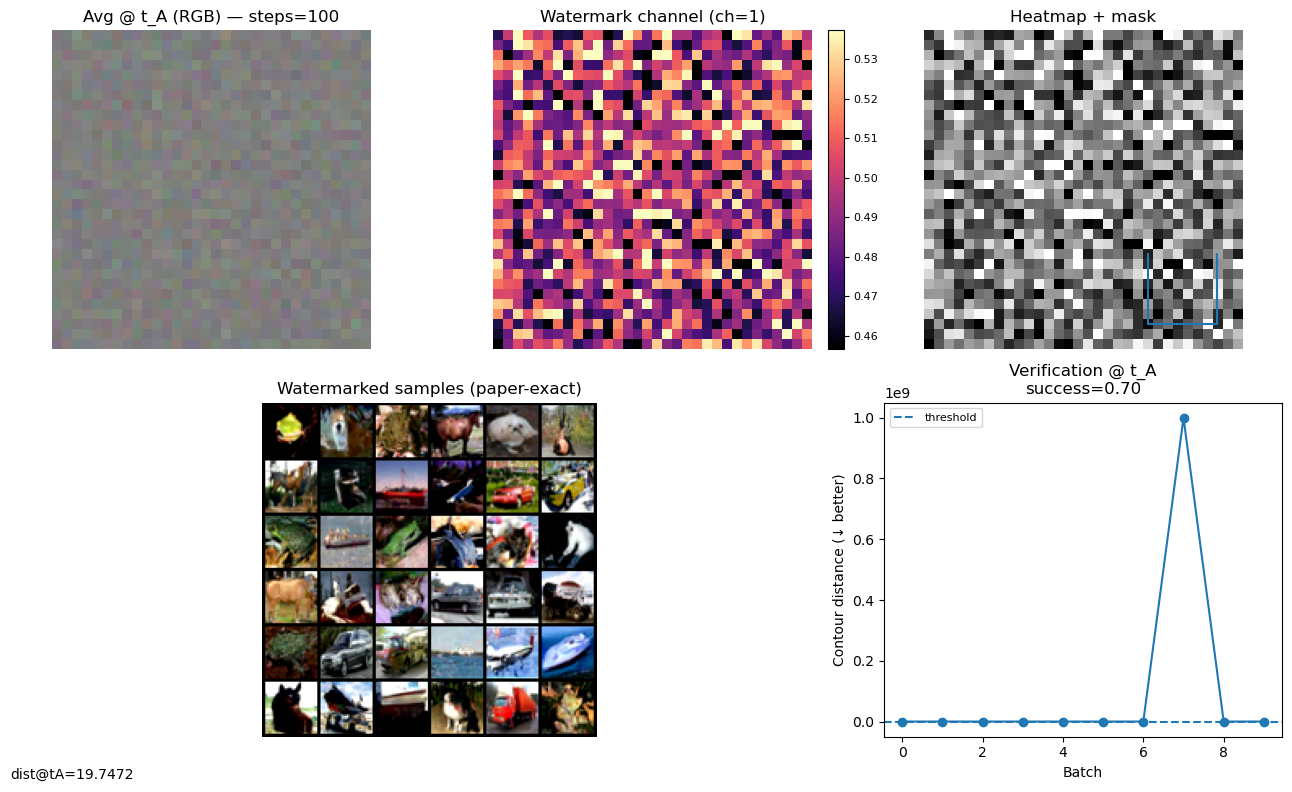

c:\Users\mike8\anaconda3\envs\pytorch\Lib\site-packages\torchmetrics\utilities\prints.py:43: UserWarning: Metric `InceptionScore` will save all extracted features in buffer. For large datasets this may lead to large memory footprint.
  warnings.warn(*args, **kwargs)  # noqa: B028


,attack,params,mean_dist,median_dist,p95_dist,success_rate(↓dist<th)
3,jpeg,{'quality': 30},9.293833e-01,6.844186e-01,2.883217e+00,0.3
6,gaussian_noise,{'std': 0.03},1.052706e+00,2.458155e-01,4.097554e+00,0.6
0,identity,{},1.068124e+00,6.955698e-01,3.478854e+00,0.4
8,crop_br,{'trim': 4},1.376766e+00,5.001017e-01,4.871967e+00,0.3
1,jpeg,{'quality': 75},1.999975e+00,1.497980e-01,6.815297e+00,0.6
11,color_jitter,"{'brightness': 0.3, 'contrast': 0.3, 'saturati...",2.827180e+00,1.365579e+00,8.576420e+00,0.3
4,gaussian_blur,"{'ksize': 3, 'sigma': 0.8}",4.106151e+00,3.460912e+00,9.710753e+00,0.3
7,resize_down_up,{'short': 16},6.412729e+00,3.204724e+00,1.967594e+01,0.2
2,jpeg,{'quality': 50},1.054836e+01,3.411227e-01,5.406420e+01,0.5
5,gaussian_blur,"{'ksize': 5, 'sigma': 1.2}",2.478550e+01,5.390003e+00,1.042461e+02,0.0


Trainable params: 35.75M / 35.75M  (100.0%), mode='all'


Fine-tuning (Alg.1, f1=0) 200 steps: 100%|██████████| 200/200 [00:57<00:00,  3.48it/s, loss=0.0259]


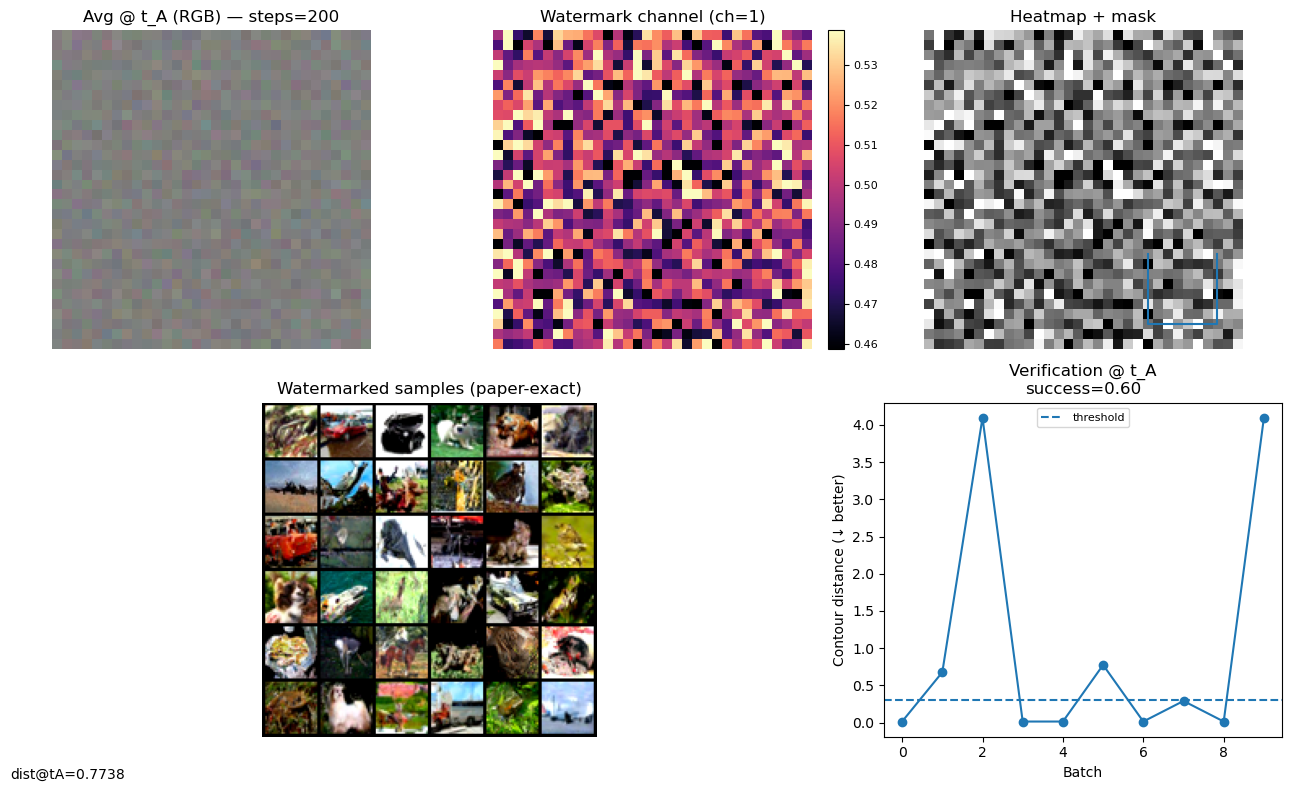

c:\Users\mike8\anaconda3\envs\pytorch\Lib\site-packages\torchmetrics\utilities\prints.py:43: UserWarning: Metric `InceptionScore` will save all extracted features in buffer. For large datasets this may lead to large memory footprint.
  warnings.warn(*args, **kwargs)  # noqa: B028


KeyboardInterrupt: 

In [ ]:
# ---------- Small config resolver ----------
def _resolve_defaults(
    lr, gamma, use_ema, verify_batches, verify_batch_size, sample_steps,
    n_final_samples, contour_threshold
):
    lr = cfg.lr if lr is None else lr
    gamma = cfg.gamma if gamma is None else gamma
    use_ema = (cfg.use_ema and channels == 3) if use_ema is None else use_ema
    verify_batches = cfg.verify_batches if verify_batches is None else verify_batches
    verify_batch_size = cfg.verify_batch_size if verify_batch_size is None else verify_batch_size
    sample_steps = cfg.sample_steps if sample_steps is None else sample_steps
    n_final_samples = cfg.n_final_samples if n_final_samples is None else n_final_samples
    contour_threshold = cfg.contour_threshold if contour_threshold is None else contour_threshold
    return (lr, gamma, use_ema, verify_batches, verify_batch_size, sample_steps,
            n_final_samples, contour_threshold)

# ---------- Model/opt/EMA prep ----------
def _prepare_models_and_opt(train_scope: str, lr: float, use_ema: bool):
    """Deep-copy baseline, unfreeze the requested scope, create optimizer and optional EMA."""
    work_unet = copy.deepcopy(baseline_unet).to(device)
    set_trainable(work_unet, mode=train_scope)

    # Optimizer over trainable params
    for p in work_unet.parameters():
        if p.requires_grad:
            p.requires_grad = True
    opt = torch.optim.AdamW(work_unet.parameters(), lr=lr, weight_decay=0.0)

    # Optional EMA for stable sampling
    ema_unet = None
    if use_ema:
        ema_unet = copy.deepcopy(work_unet).eval()
        for p in ema_unet.parameters():
            p.requires_grad = False
    ema_decay = 0.999
    return work_unet, opt, ema_unet, ema_decay

# ---------- One training step: build biased inputs/targets ----------
def _build_biased_batch(x0: torch.Tensor, t: torch.Tensor, gamma: float):
    """
    Implements Algorithm 1 (f1=0):
      - For t <= tA: inject watermark into input x'_t and shift target ε''_t.
      - For t  > tA: simulate from x'_{tA} to t, target is plain ε'.
    Returns:
      x_t_prime  (input to UNet), shape [B,C,H,W]
      eps_dprime (target),       shape [B,C,H,W]
    """
    # Base forward noising q(x_t | x0)
    eps_prime = torch.randn_like(x0)
    x_sim = scheduler.add_noise(x0, eps_prime, t)

    x_t_prime    = x_sim.clone()
    eps_dblprime = eps_prime.clone()

    # Embedding stage (t <= tA)
    embed = (t <= tA)
    if embed.any():
        idx        = embed.nonzero(as_tuple=False).squeeze(1)
        sqrt_ab_t  = (a_bar.index_select(0, t[idx]).view(-1,1,1,1)).sqrt()
        sqrt_1m_t  = (1 - a_bar.index_select(0, t[idx]).view(-1,1,1,1)).sqrt()
        f2_t       = f2.index_select(0, t[idx]).view(-1,1,1,1)
        dyn_t      = sqrt_1m_a_bar.index_select(0, t[idx]).view(-1,1,1,1)  # √(1-ᾱ_t)
        bt         = (f2_t * dyn_t) * xA
        b0_term    = sqrt_ab_t * b0

        # x'_t = √ᾱ_t x0 + γ √(1-ᾱ_t) ε' + (1-γ)(b_t - √ᾱ_t b0)
        x_t_prime[idx] = (
            sqrt_ab_t * x0[idx]
            + gamma * sqrt_1m_t * eps_prime[idx]
            + (1 - gamma) * (bt - b0_term)
        )
        # ε''_t = γ ε' + (1-γ) K x_A
        eps_dblprime[idx] = gamma * eps_prime[idx] + (1 - gamma) * (K * xA)

    # Simulation stage (t > tA): from x'_{tA}, no target shift
    sim = ~embed
    if sim.any():
        idx = sim.nonzero(as_tuple=False).squeeze(1)
        B2 = idx.numel()
        tA_tensor = torch.full((B2,), tA, device=device, dtype=torch.long)
        sqrt_ab_tA  = (a_bar.index_select(0, tA_tensor).view(-1,1,1,1)).sqrt()
        sqrt_1m_tA  = (1 - a_bar.index_select(0, tA_tensor).view(-1,1,1,1)).sqrt()
        f2_tA       = f2.index_select(0, tA_tensor).view(-1,1,1,1)
        dyn_tA      = sqrt_1m_a_bar.index_select(0, tA_tensor).view(-1,1,1,1)
        eps_prime_tA = torch.randn_like(x0[idx])
        btA      = (f2_tA * dyn_tA) * xA
        b0_termA = sqrt_ab_tA * b0
        x_tA_prime = (
            sqrt_ab_tA * x0[idx]
            + gamma * sqrt_1m_tA * eps_prime_tA
            + (1 - gamma) * (btA - b0_termA)
        )
        ratio = (a_bar.index_select(0, t[idx]).view(-1,1,1,1) / a_bar[tA]).clamp(min=1e-12)
        x_t_prime[idx] = ratio.sqrt() * x_tA_prime + (1 - ratio).sqrt() * eps_prime[idx]
        eps_dblprime[idx] = eps_prime[idx]

    return x_t_prime, eps_dblprime

# ---------- Full fine-tuning loop ----------
def _run_finetune(
    work_unet, opt, ema_unet, ema_decay, max_steps: int, gamma: float
):
    work_unet.train()
    pbar = tqdm(range(max_steps), desc=f"Fine-tuning (Alg.1, f1=0) {max_steps} steps")
    data_iter = iter(train_loader)
    loss_traj = []

    for _ in pbar:
        # Fetch batch (recycle loader if needed)
        try:
            x0, _ = next(data_iter)
        except StopIteration:
            data_iter = iter(train_loader)
            x0, _ = next(data_iter)

        x0 = x0.to(device)
        B = x0.size(0)
        t = torch.randint(0, T, (B,), device=device, dtype=torch.long)

        # Build input/target for current t
        x_t_prime, eps_dblprime = _build_biased_batch(x0, t, gamma)

        # Predict and update
        noise_pred = work_unet(x_t_prime, t, return_dict=False)[0]
        loss = F.mse_loss(noise_pred, eps_dblprime)

        opt.zero_grad(set_to_none=True)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(work_unet.parameters(), 1.0)
        opt.step()

        # EMA
        if ema_unet is not None:
            with torch.no_grad():
                for pe, p in zip(ema_unet.parameters(), work_unet.parameters()):
                    pe.mul_(ema_decay).add_(p, alpha=1.0 - ema_decay)

        loss_val = float(loss.detach().cpu())
        loss_traj.append(loss_val)
        pbar.set_postfix(loss=loss_val)

    # Choose sampler
    sampler_unet = ema_unet if (ema_unet is not None and channels == 3) else work_unet
    sampler_unet.eval()
    return sampler_unet, loss_traj

# ---------- Detection: average at t_A & distance ----------
@torch.no_grad()
def _detect_at_tA(sampler_unet, sample_steps: int, gamma: float):
    """Return averaged mid-state x̄_{t_A} in [0,1], its uint8 channel, and contour distance."""
    xmid = _sample_mid_after(sampler_unet, scheduler, n=cfg.verify_batch_size,
                             steps=sample_steps, capture_tA=tA, gamma=gamma)
    xavg = xmid.mean(dim=0, keepdim=True)  # [1,C,H,W] in [0,1]
    xavg_u8 = to_u8(xavg)[0]
    mask_u8 = (xA[WTMK_CH].detach().cpu().numpy() > 0).astype(np.uint8) * 255
    dist_tA = float(contour_distance_strict(xavg_u8[WTMK_CH].numpy(), mask_u8))
    ch = xavg[0, WTMK_CH].cpu().numpy()
    lo, hi = np.percentile(ch, [5, 95]); 
    if hi <= lo: hi = lo + 1e-3
    return xavg, xavg_u8, ch, (lo, hi), mask_u8, dist_tA

# ---------- Verification: multiple averages ----------
@torch.no_grad()
def _verify_batches(sampler_unet, sample_steps: int, gamma: float,
                    batches: int, batch_size: int, threshold: float):
    """Repeat averaging at t_A and compute contour distances across 'batches' trials."""
    mask_u8_local = (xA[WTMK_CH].detach().cpu().numpy() > 0).astype(np.uint8) * 255
    dists = []
    for _ in range(batches):
        _, xmid_ = sample_paper(sampler_unet, scheduler, n=batch_size,
                                steps=sample_steps, capture_tA=tA, gamma=gamma)
        xavg_ = xmid_.mean(dim=0, keepdim=True)
        xavg_u8_ = to_u8(xavg_)[0, WTMK_CH].numpy()
        dists.append(contour_distance_strict(xavg_u8_, mask_u8_local))
    arr = np.array(dists, dtype=np.float32)
    success = float((arr < threshold).mean())
    return arr, success

# ---------- Visualization ----------
def _build_summary_figure(max_steps: int, xavg, ch, lo, hi,
                          grid_np, distances, contour_threshold, dist_tA, mask_u8):
    """Compose the one-page report figure."""
    contours, _ = cv2.findContours(mask_u8, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    fig = plt.figure(figsize=(13, 8))
    gs = fig.add_gridspec(2, 3, height_ratios=[1, 1.05])
    ax1 = fig.add_subplot(gs[0, 0])
    ax2 = fig.add_subplot(gs[0, 1])
    ax3 = fig.add_subplot(gs[0, 2])
    ax4 = fig.add_subplot(gs[1, 0:2])
    ax5 = fig.add_subplot(gs[1, 2])

    # (1) Avg RGB @ t_A
    ax1.imshow(xavg[0].permute(1, 2, 0).cpu().numpy())
    ax1.set_title(f"Avg @ t_A (RGB) — steps={max_steps}")
    ax1.axis("off")

    # (2) Watermark channel heatmap
    im2 = ax2.imshow(ch, cmap="magma", vmin=lo, vmax=hi)
    ax2.set_title(f"Watermark channel (ch={WTMK_CH})")
    ax2.axis("off")
    cbar = fig.colorbar(im2, ax=ax2, fraction=0.046, pad=0.04)
    cbar.ax.tick_params(labelsize=8)

    # (3) Mask overlay
    ax3.imshow(ch, cmap="gray", vmin=lo, vmax=hi)
    for c in contours:
        c = c.squeeze(1)
        ax3.plot(c[:, 0], c[:, 1], linewidth=1.5)
    ax3.set_title("Heatmap + mask")
    ax3.axis("off")

    # (4) Final sample grid
    ax4.imshow(grid_np)
    ax4.set_title("Watermarked samples (paper-exact)")
    ax4.axis("off")

    # (5) Contour distances across verification batches
    xs = np.arange(len(distances))
    ax5.plot(xs, distances, marker='o')
    ax5.axhline(contour_threshold, linestyle='--', label='threshold')
    ax5.set_xlabel("Batch")
    ax5.set_ylabel("Contour distance (↓ better)")
    ax5.set_title(f"Verification @ t_A\nsuccess={(distances < contour_threshold).mean():.2f}")
    ax5.legend(loc="best", fontsize=8)

    fig.text(0.01, 0.02, f"dist@tA={dist_tA:.4f}", fontsize=10)
    fig.tight_layout()
    return fig

# ---------- Optional: quality metrics (IS/FID/Precision/Recall/sFID placeholder) ----------
def _compute_quality_metrics_if_requested(
    compute_metrics: bool, sampler_unet, sample_steps: int, gamma: float,
    metrics_num_gen: int, metrics_num_real: int, metrics_splits: int
):
    metrics = {"IS": None, "FID": None, "Precision": None, "Recall": None}
    if not compute_metrics:
        return metrics

    try:
        real_u8 = _collect_real_u8(train_loader, metrics_num_real)     # [Nr,C,H,W] uint8 CPU
        gen_u8  = _generate_u8(sampler_unet, scheduler, metrics_num_gen,
                               steps=sample_steps, gamma=gamma)         # [Nf,C,H,W] uint8 CPU
    except Exception as e:
        print(f"[warn] collecting real/gen failed: {e}")
        return metrics

    # Inception Score
    try:
        from torchmetrics.image.inception import InceptionScore
        is_metric = InceptionScore(splits=metrics_splits, normalize=False).to(device)
        for i in range(0, gen_u8.shape[0], 128):
            is_metric.update(gen_u8[i:i+128].to(device))
        IS_mean, IS_std = is_metric.compute()
        metrics["IS"] = (float(IS_mean), float(IS_std))
    except Exception as e:
        print(f"[warn] IS failed: {e}")

    # FID
    try:
        from torchmetrics.image.fid import FrechetInceptionDistance
        fid = FrechetInceptionDistance(normalize=False).to(device)
        for i in range(0, real_u8.shape[0], 128):
            fid.update(real_u8[i:i+128].to(device), real=True)
        for i in range(0, gen_u8.shape[0], 128):
            fid.update(gen_u8[i:i+128].to(device), real=False)
        metrics["FID"] = float(fid.compute().item())
    except Exception as e:
        print(f"[warn] FID failed: {e}")

    # Precision/Recall
    try:
        feats_real = _inception_feats_u8(real_u8, device=device, batch=128)
        feats_fake = _inception_feats_u8(gen_u8,  device=device, batch=128)
        P, R = _precision_recall_knn(feats_real, feats_fake, k=3, chunk=1024, device=device)
        
        metrics["Precision"] = float(P)
        metrics["Recall"]    = float(R)
    except Exception as e:
        print(f"[warn] Precision/Recall failed: {e}")

    # sFID left as None unless you wire an implementation.
    return metrics


import io, math, pandas as pd
from PIL import Image
import torchvision.transforms.functional as TVF
import torch.nn.functional as tF  # don't confuse with TVF

def _to_u8_np(img_f01_chw: torch.Tensor) -> np.ndarray:
    """[C,H,W] float[0,1] -> uint8 HxWxC (numpy)."""
    x = (img_f01_chw.clamp(0,1) * 255.0).to(torch.uint8).permute(1,2,0).cpu().numpy()
    return x

def _u8_np_to_f01_chw(arr_u8: np.ndarray) -> torch.Tensor:
    """uint8 HxWxC -> [C,H,W] float[0,1] torch CPU."""
    x = torch.from_numpy(arr_u8.astype(np.float32) / 255.0).permute(2,0,1)
    return x

def _jpeg_compress_tensor(img_f01_chw: torch.Tensor, quality: int = 50) -> torch.Tensor:
    """Per-image JPEG round-trip."""
    u8 = _to_u8_np(img_f01_chw)
    pil = Image.fromarray(u8)
    buf = io.BytesIO()
    pil.save(buf, format="JPEG", quality=int(quality))
    buf.seek(0)
    out = Image.open(buf).convert("RGB")
    return _u8_np_to_f01_chw(np.array(out, dtype=np.uint8))

def _apply_attack_image(x01_chw: torch.Tensor, kind: str, **p) -> torch.Tensor:
    """Apply one attack to a single CHW tensor in [0,1] (CPU)."""
    if kind == "identity":
        return x01_chw
    if kind == "hflip":
        return TVF.hflip(x01_chw)
    if kind == "vflip":
        return TVF.vflip(x01_chw)
    if kind == "rotate":
        deg = float(p.get("degrees", 15.0))
        return TVF.rotate(x01_chw, angle=deg, interpolation=TVF.InterpolationMode.BILINEAR, fill=0.5)
    if kind == "gaussian_blur":
        k = int(p.get("ksize", 3)); s = float(p.get("sigma", 0.8))
        k = k if k % 2 == 1 else k+1
        return TVF.gaussian_blur(x01_chw, [k, k], sigma=[s, s])
    if kind == "gaussian_noise":
        std = float(p.get("std", 0.03))
        n = torch.randn_like(x01_chw) * std
        return (x01_chw + n).clamp(0.0, 1.0)
    if kind == "resize_down_up":
        short = int(p.get("short", 24))
        C,H,W = x01_chw.shape
        # keep aspect (square here), down then up with bilinear
        x = x01_chw.unsqueeze(0)
        x = tF.interpolate(x, size=(short, short), mode="bilinear", align_corners=False)
        x = tF.interpolate(x, size=(H, W), mode="bilinear", align_corners=False)
        return x[0]
    if kind == "crop_br":
        # Crop off 'trim' pixels along bottom & right, then resize back (destroys BR watermark region).
        trim = int(p.get("trim", 4))
        C,H,W = x01_chw.shape
        h2, w2 = max(1, H-trim), max(1, W-trim)
        x = x01_chw[:, :h2, :w2].unsqueeze(0)
        x = tF.interpolate(x, size=(H, W), mode="bilinear", align_corners=False)
        return x[0]
    if kind == "jpeg":
        q = int(p.get("quality", 50))
        # ensure 3 channels for JPEG; if grayscale, tile
        x = x01_chw
        if x.shape[0] == 1:
            x = x.repeat(3,1,1)
        x = _jpeg_compress_tensor(x, quality=q)
        # If original was 1ch, reduce back to 1ch by luminance
        if x01_chw.shape[0] == 1:
            x = x.mean(dim=0, keepdim=True)
        return x
    if kind == "color_jitter":
        br = 1.0 + float(p.get("brightness", 0.0))   # multiplier
        ct = 1.0 + float(p.get("contrast", 0.0))
        st = 1.0 + float(p.get("saturation", 0.0))
        x = x01_chw
        # Only apply saturation if RGB
        x = TVF.adjust_brightness(x, br)
        x = TVF.adjust_contrast(x, ct)
        if x.shape[0] == 3:
            x = TVF.adjust_saturation(x, st)
        return x.clamp(0,1)
    if kind == "channel_dropout":
        ch = int(p.get("ch", WTMK_CH))
        x = x01_chw.clone()
        if 0 <= ch < x.shape[0]:
            x[ch] = 0.5  # neutral fill
        return x
    raise ValueError(f"Unknown attack kind: {kind}")

def _apply_attack_batch(x01_bchw: torch.Tensor, kind: str, **p) -> torch.Tensor:
    """Vectorized wrapper (loops on CPU) for a batch [B,C,H,W] in [0,1]."""
    x = x01_bchw.cpu()
    out = []
    for i in range(x.size(0)):
        out.append(_apply_attack_image(x[i], kind, **p))
    return torch.stack(out, dim=0)  # CPU, [B,C,H,W], float[0,1]

@torch.no_grad()
def _verify_under_attack(
    sampler_unet, scheduler_like, *,
    attack_kind: str, attack_params: dict,
    batches: int, batch_size: int, steps: int, tA_idx: int, gamma: float, threshold: float
):
    """Repeat: sample x_{t_A}, apply attack to each sample, average, contour distance."""
    mask_u8_local = (xA[WTMK_CH].detach().cpu().numpy() > 0).astype(np.uint8) * 255
    dists = []
    for _ in range(batches):
        # paper-exact mid-state sampling in [0,1]
        _, xmid = sample_paper(sampler_unet, scheduler_like, n=batch_size, steps=steps, capture_tA=tA_idx, gamma=gamma)
        # apply attack to every sample BEFORE averaging
        xmid_att = _apply_attack_batch(xmid, attack_kind, **(attack_params or {}))
        xavg_att = xmid_att.mean(dim=0, keepdim=True)
        xavg_u8  = to_u8(xavg_att)[0, WTMK_CH].numpy()
        d = contour_distance_strict(xavg_u8, mask_u8_local)
        dists.append(d)
    arr = np.array(dists, dtype=np.float32)
    success = float((arr < threshold).mean())
    return arr, success

def run_attack_suite(
    sampler_unet, *,
    steps: int = None,
    batches: int = None,
    batch_size: int = None,
    threshold: float = None,
    suite: list | None = None
):
    """Evaluate robustness across a set of attacks; returns a DataFrame."""
    steps     = cfg.sample_steps if steps is None else steps
    batches   = cfg.verify_batches if batches is None else batches
    batch_size= cfg.verify_batch_size if batch_size is None else batch_size
    threshold = cfg.contour_threshold if threshold is None else threshold

    # Default suite mixes photometric & geometric attacks + a targeted crop of BR area.
    if suite is None:
        suite = [
            ("identity",           {}),
            ("jpeg",               {"quality": 75}),
            ("jpeg",               {"quality": 50}),
            ("jpeg",               {"quality": 30}),
            ("gaussian_blur",      {"ksize": 3, "sigma": 0.8}),
            ("gaussian_blur",      {"ksize": 5, "sigma": 1.2}),
            ("gaussian_noise",     {"std": 0.03}),
            ("resize_down_up",     {"short": max(8, cfg.image_size//2)}),
            ("crop_br",            {"trim": max(2, cfg.box_size//2)}),  # directly attacks BR watermark
            ("rotate",             {"degrees": 15}),
            ("hflip",              {}),
            ("color_jitter",       {"brightness": 0.3, "contrast": 0.3, "saturation": 0.3}),
            ("channel_dropout",    {"ch": WTMK_CH}),  # adversarial to channel-carried marks
        ]

    rows = []
    for (name, params) in suite:
        arr, succ = _verify_under_attack(
            sampler_unet, scheduler_like=scheduler,
            attack_kind=name, attack_params=params,
            batches=batches, batch_size=batch_size,
            steps=steps, tA_idx=tA, gamma=cfg.gamma, threshold=threshold
        )
        rows.append({
            "attack": name,
            "params": params,
            "mean_dist": float(arr.mean()),
            "median_dist": float(np.median(arr)),
            "p95_dist": float(np.percentile(arr, 95)),
            "success_rate(↓dist<th)": float(succ),
        })
    df = pd.DataFrame(rows).sort_values("mean_dist")
    display(df)
    return df

# -----------------------------------------------------------------------------
# Main: Fine-tune the model and produce ONE combined figure summarizing the run
# -----------------------------------------------------------------------------
def finetune_and_report(
    max_steps: int,
    *,
    lr: float = None,
    gamma: float = None,
    use_ema: bool = None,
    verify_batches: int = None,
    verify_batch_size: int = None,
    sample_steps: int = None,
    n_final_samples: int = None,
    contour_threshold: float = None,
    return_models: bool = False,
    show: bool = True,
    train_scope: str = "all",  # {"all","last_conv","last_block","last_two_blocks"}
    compute_metrics: bool = True,
    metrics_num_gen: int = 2048,
    metrics_num_real: int = 2048,
    metrics_splits: int = 10,
):
    # 1) Defaults
    (lr, gamma, use_ema, verify_batches, verify_batch_size, sample_steps,
     n_final_samples, contour_threshold) = _resolve_defaults(
        lr, gamma, use_ema, verify_batches, verify_batch_size, sample_steps,
        n_final_samples, contour_threshold
    )

    # 2) Prep models/opt/EMA
    work_unet, opt, ema_unet, ema_decay = _prepare_models_and_opt(train_scope, lr, use_ema)

    # 3) Fine-tune
    sampler_unet, loss_traj = _run_finetune(work_unet, opt, ema_unet, ema_decay, max_steps, gamma)

    # 4) Detect watermark at t_A (avg)
    xavg, xavg_u8, ch, (lo, hi), mask_u8, dist_tA = _detect_at_tA(
        sampler_unet, sample_steps=sample_steps, gamma=gamma
    )

    # 5) Final samples (quality eyeballing)
    imgs_wtmk, _ = sample_paper(sampler_unet, scheduler, n=n_final_samples,
                                steps=sample_steps, capture_tA=tA, gamma=gamma)
    grid = make_grid(imgs_wtmk, nrow=int(np.sqrt(n_final_samples)), padding=2)
    grid_np = (grid.detach().cpu().permute(1, 2, 0).numpy() * 255).astype(np.uint8)

    # 6) Verification batches (Contour distance ONLY)
    distances, success = _verify_batches(
        sampler_unet, sample_steps=sample_steps, gamma=gamma,
        batches=verify_batches, batch_size=verify_batch_size,
        threshold=contour_threshold
    )

    # 7) Figure
    fig = _build_summary_figure(
        max_steps, xavg, ch, lo, hi, grid_np, distances, contour_threshold, dist_tA, mask_u8
    )
    if show:
        plt.show()

    # 8) Optional quality metrics (IS/FID/sFID/Precision/Recall)
    metrics = _compute_quality_metrics_if_requested(
        compute_metrics, sampler_unet, sample_steps, gamma,
        metrics_num_gen, metrics_num_real, metrics_splits
    )

    # 9) Results dict (+ optional models)
    result = {
        "max_steps": max_steps,
        "loss_traj": loss_traj,
        "xavg_tA": xavg,                     # [1,C,H,W] in [0,1]
        "samples": imgs_wtmk,                # [N,C,H,W] in [0,1]
        "contour_distance_tA": dist_tA,
        "verify_distances": distances,       # np.array of distances
        "verify_success": float(success),    # fraction < threshold
        **metrics,                  # IS/FID/... (may be None)
    }

    if return_models:
        result.update({"unet": work_unet, "ema_unet": ema_unet, "sampler_unet": sampler_unet})

    return result, fig

print("Running fine-tuning sweep (all layers) + attacks…")
results = []
attack_rows = []  # long-form per-attack table

for steps in cfg.finetune_sweep:
    # return_models=True so we can run the attack suite on the actual sampler UNet
    res, fig = finetune_and_report(steps, show=True, train_scope="all", return_models=False)

    # Run jailbreak/attack suite for THIS trained model
    # atk_df = run_attack_suite(res["sampler_unet"])

    # # ---- plug attack_df into the result ----
    # res["attack_df"] = atk_df
    # # also store a JSON-serializable summary for quick comparisons
    # res["attack_summary"] = atk_df[["attack","params","mean_dist","median_dist","p95_dist","success_rate(↓dist<th)"]].to_dict("records")

    # # build a long-form table (one row per attack per run)
    # for _, r in atk_df.iterrows():
    #     attack_rows.append({
    #         "train_scope": "all",
    #         "max_steps":   res["max_steps"],
    #         "attack":      r["attack"],
    #         "params":      r["params"],
    #         "mean_dist":   r["mean_dist"],
    #         "median_dist": r["median_dist"],
    #         "p95_dist":    r["p95_dist"],
    #         "success_rate": r["success_rate(↓dist<th)"],
    #     })

    # # drop heavy model refs before collecting results
    # res.pop("sampler_unet", None)
    # res.pop("unet", None)
    # res.pop("ema_unet", None)

    results.append(res)

# High-level summary per run (you can add/remove columns as you like)
summary_cols = ["max_steps", "contour_distance_tA", "verify_success", "IS", "FID", "Precision", "Recall"]
display(pd.DataFrame(results)[[c for c in summary_cols if c in pd.DataFrame(results).columns]])

# Long-form per-attack table for this sweep
# attack_long_all = pd.DataFrame(attack_rows)
# display(attack_long_all.sort_values(["mean_dist", "p95_dist"]))


# ---------------- Run fine-tuning sweep (last block only) + jailbreak suite ----------------
print("Running fine-tuning sweep (last block only) + attacks…")
last_block_results = []
attack_rows_last = []

for steps in cfg.finetune_sweep:
    res, fig = finetune_and_report(steps, train_scope="last_block", show=True, return_models=False)

    # atk_df = run_attack_suite(res["sampler_unet"])
    # res["attack_df"] = atk_df
    # res["attack_summary"] = atk_df[["attack","params","mean_dist","median_dist","p95_dist","success_rate(↓dist<th)"]].to_dict("records")

    # for _, r in atk_df.iterrows():
    #     attack_rows_last.append({
    #         "train_scope": "last_block",
    #         "max_steps":   res["max_steps"],
    #         "attack":      r["attack"],
    #         "params":      r["params"],
    #         "mean_dist":   r["mean_dist"],
    #         "median_dist": r["median_dist"],
    #         "p95_dist":    r["p95_dist"],
    #         "success_rate": r["success_rate(↓dist<th)"],
    #     })

    # res.pop("sampler_unet", None)
    # res.pop("unet", None)
    # res.pop("ema_unet", None)

    last_block_results.append(res)

display(pd.DataFrame(last_block_results)[[c for c in summary_cols if c in pd.DataFrame(last_block_results).columns]])

# attack_long_last = pd.DataFrame(attack_rows_last)
# display(attack_long_last.sort_values(["mean_dist", "p95_dist"]))

In [ ]:
sweep

# Findings

